In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [136]:
df=pd.read_csv("smartcart_customers.csv")

In [137]:
df.head()
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

Data Preprocessing

1-Handling Missing

In [138]:
df["Income"]=df["Income"].fillna(df['Income'].median())

In [139]:
df.head()
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

Feature Engineering

In [140]:
#Age
df["Age"]=2026-df["Year_Birth"]

In [141]:
#Customers Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days


In [142]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [143]:
#About Total Spending
df["total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntFishProducts"]+df["MntMeatProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [144]:
#Childern
df["total_childern"]=df["Kidhome"]+df["Teenhome"]

In [147]:
#About Education 
df["Education"].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate","2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "PhD":"PostGraduate","Master":"PostGraduate"
})

In [148]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [149]:
#Marital Status
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"together","Together":"together",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Alone":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})


In [150]:
df["Living_With"].value_counts()

Living_With
together    1444
Alone        796
Name: count, dtype: int64

Drop Columns

In [151]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'total_spending',
       'total_childern', 'Living_With'],
      dtype='object')

In [152]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome","Dt_Customer"]
spending_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [153]:
df_cleaned.shape
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'total_spending', 'total_childern',
       'Living_With'],
      dtype='object')

Outliers

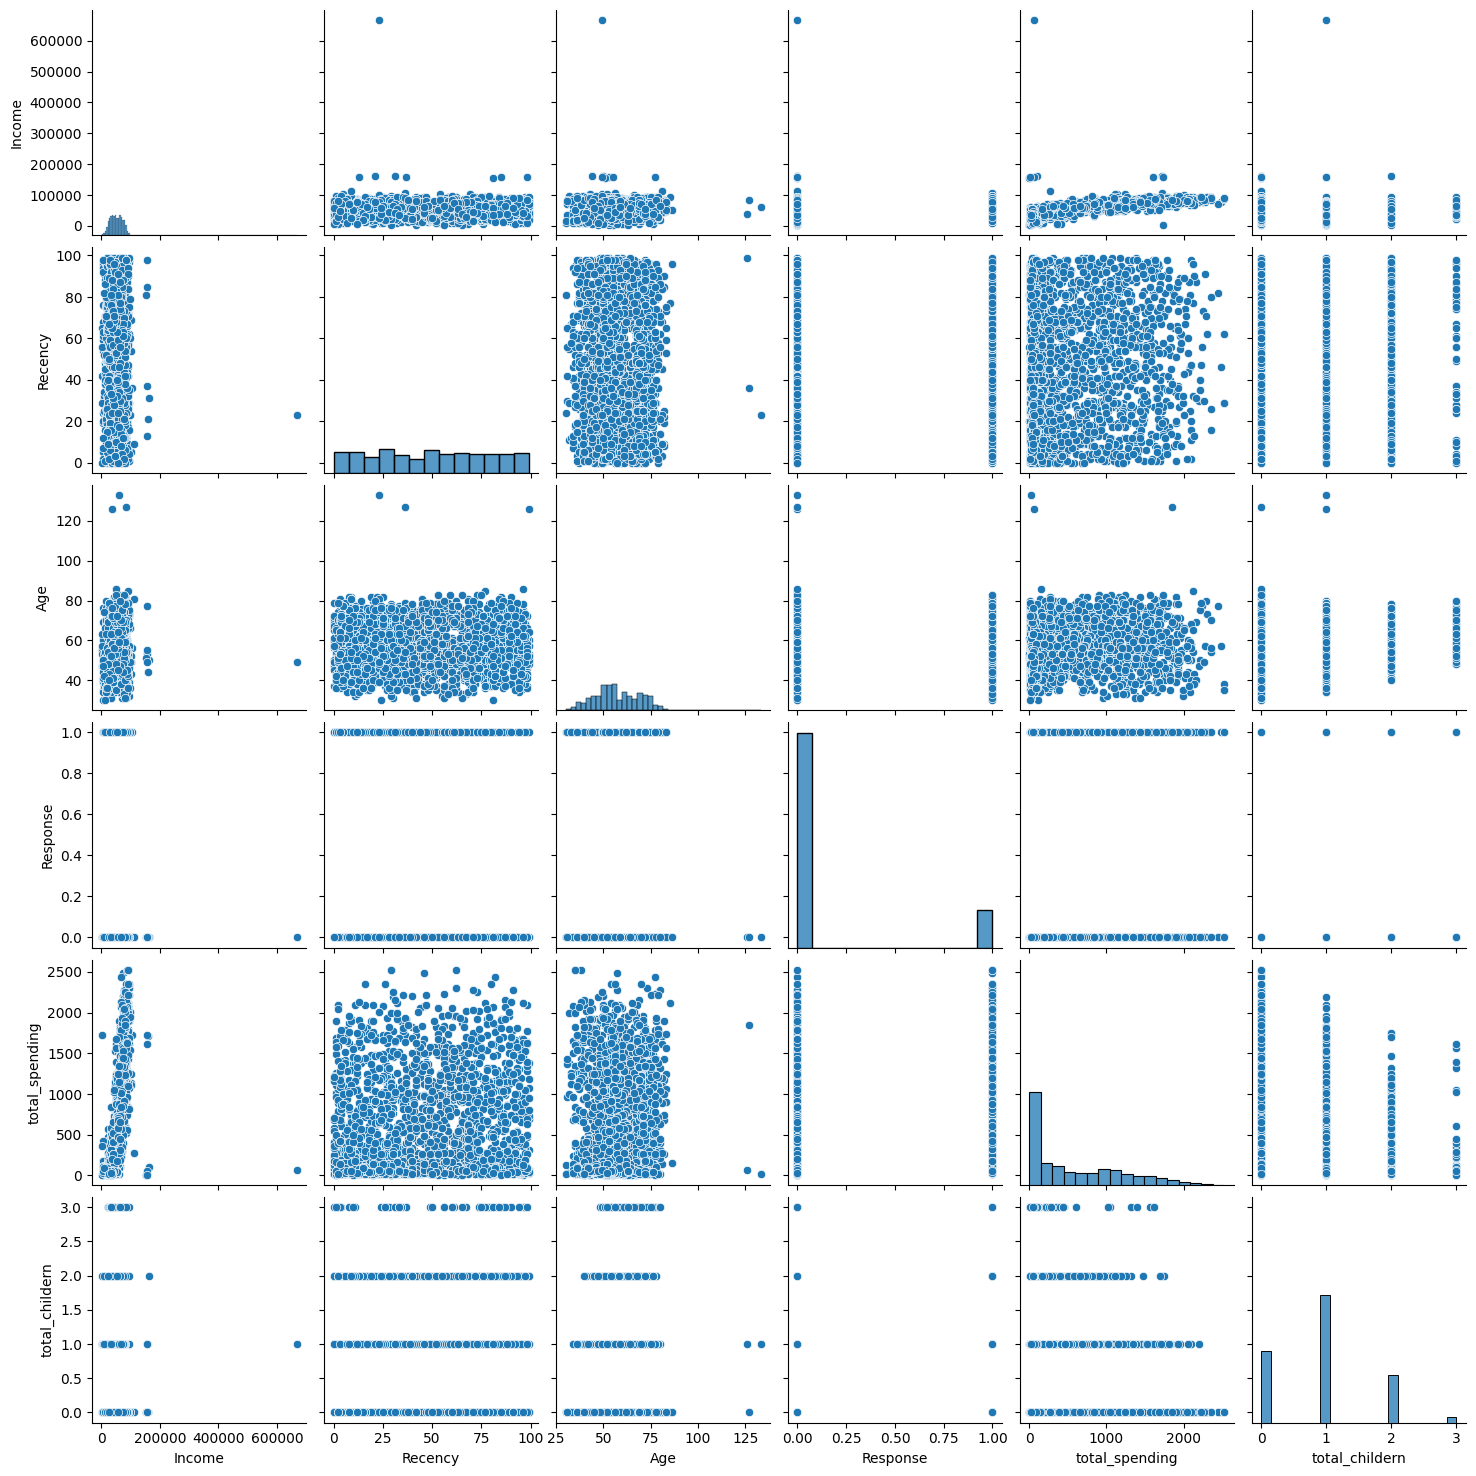

In [154]:
cols=["Income","Recency","Age","Response","total_spending","total_childern"]
sns.pairplot(df_cleaned[cols])

In [155]:
#Remove outliers
print("Data with outliers",len(df_cleaned))
df_cleaned=df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned=df_cleaned[ (df_cleaned["Income"]<600_000) ]

print("Data without outliers",len(df_cleaned))

Data with outliers 2240
Data without outliers 2236


Heatmap

<Axes: >

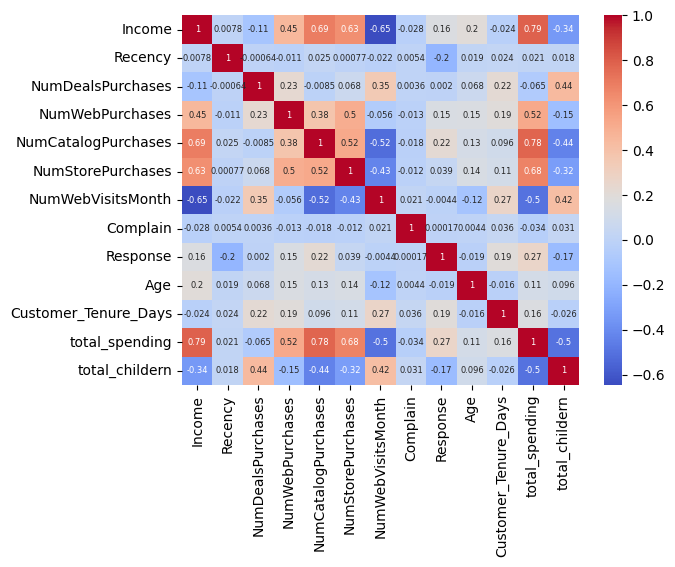

In [156]:
corr=df_cleaned.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

Feature Encoding

In [157]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [159]:
df_encoded.head()
# df_encoded.shape

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,total_childern,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_together
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


Standardizing our Data

In [160]:
X=df_encoded

scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)


Visualization

array([0.23163158, 0.11385454, 0.10405815])

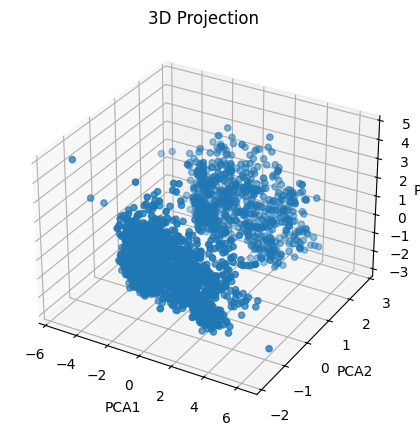

In [161]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

fig=plt.figure(figsize=(5,8))
axe=fig.add_subplot(111,projection='3d')
axe.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

axe.set_xlabel("PCA1")
axe.set_ylabel("PCA2")
axe.set_zlabel("PCA3")
axe.set_title("3D Projection")
pca.explained_variance_ratio_

Analyze the K value

1-Elbow Method

In [162]:
wcss=[]
for k in range(1,10):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [163]:
knee=KneeLocator(range(1,10),wcss,curve='convex',direction='decreasing')
optimal_k=knee.elbow
print('Best K: ',optimal_k)

Best K:  4


Text(0.5, 1.0, 'Elbow Method')

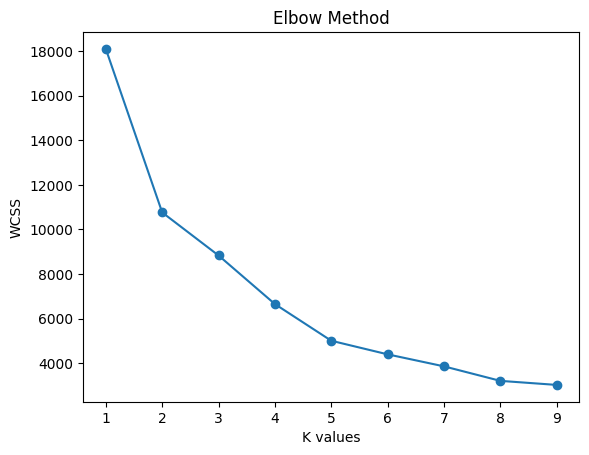

In [164]:
plt.plot(range(1,10),wcss,marker='o')
plt.xlabel("K values")
plt.ylabel("WCSS")
plt.title('Elbow Method')

2-Silhoutte Score Method

In [165]:
scores=[]
for k in  range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

Text(0.5, 1.0, 'Silhoute Score Method')

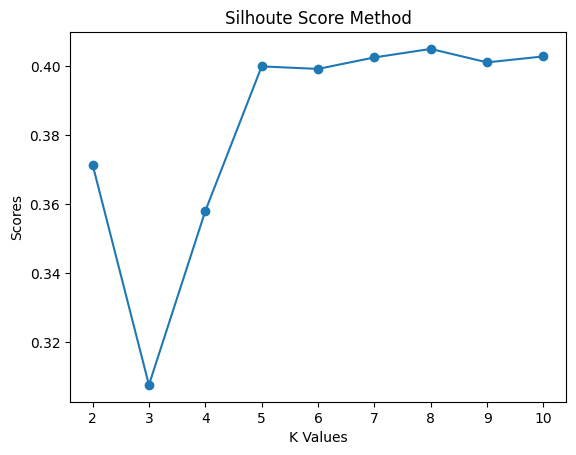

In [166]:
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K Values")
plt.ylabel("Scores")
plt.title("Silhoute Score Method")

Text(0, 0.5, 'SS')

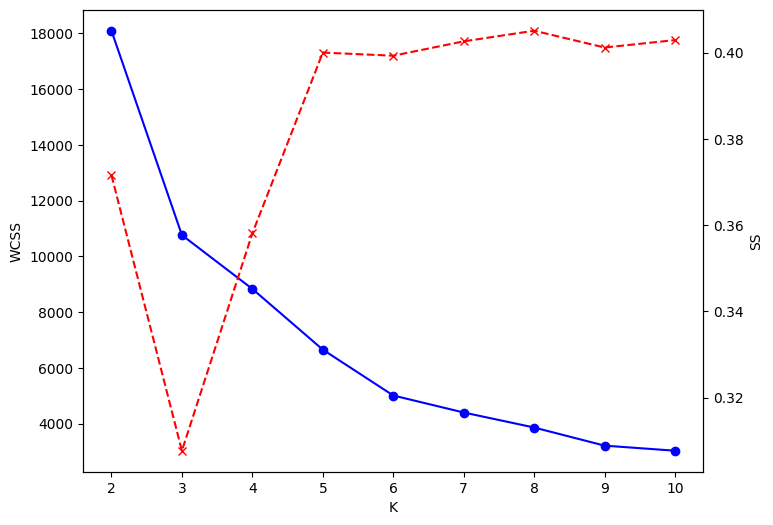

In [167]:
#Now ploting combine Plot
krange=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(krange,wcss[:len(krange)],marker='o',color='blue')
ax1.set_xlabel('K')
ax1.set_ylabel('WCSS')
ax2=ax1.twinx()
ax2.plot(krange,scores[:len(krange)],marker='x',color='red',linestyle='--')
ax2.set_ylabel("SS")

Clustering Algorithms 

In [168]:
#Applying Kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(x_pca)

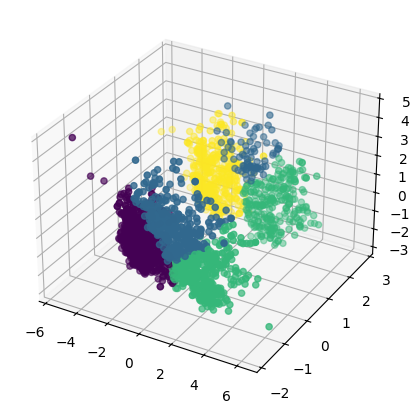

In [169]:
fig=plt.figure(figsize=(5,8))
axe=fig.add_subplot(111,projection='3d')
axe.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

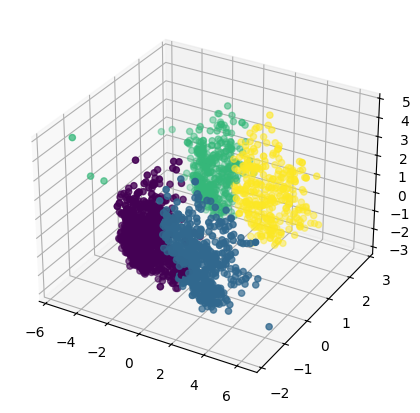

In [170]:
#Agglomerative Clustering
agg_cl=AgglomerativeClustering(n_clusters=4,linkage='ward')
agg_labels=agg_cl.fit_predict(x_pca)
fig=plt.figure(figsize=(5,8))
axe=fig.add_subplot(111,projection='3d')
axe.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=agg_labels)

Charaterization of Clusters

In [181]:
X['clusters']=agg_labels

In [182]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,total_childern,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_together,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

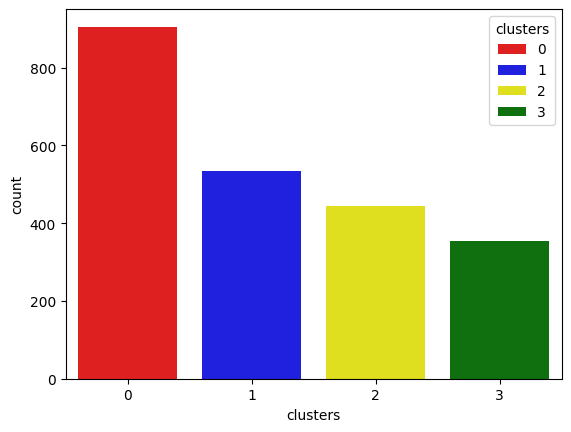

In [183]:
pal=['red','blue','yellow','green']
sns.countplot(x=X['clusters'],palette=pal,hue=X['clusters'])

<Axes: xlabel='total_spending', ylabel='Income'>

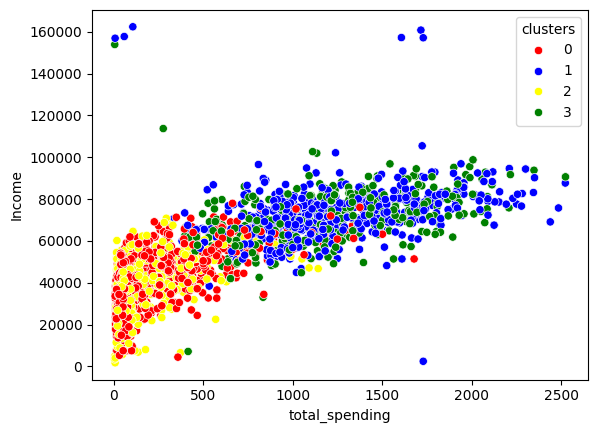

In [184]:
#Now cheking for relation beween spending and income
sns.scatterplot(x=X['total_spending'],y=X['Income'],hue=X['clusters'],palette=pal)

#Cluster Summury for profiling

In [186]:
cluster_summary=X.groupby('clusters').mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  total_spending  \
clu